# Hindsight Paystub CBA v2 — Tesseract + LLM Two-Stage

**Goal**: Force real concept binding by using a non-semantic OCR engine for extraction.

**Problem with LLM-only two-stage**: Even when Stage 1 is "just extract labels", the LLM semantically interprets the document — outputting clean labels like `"Employee Name"` instead of the raw text `"EMPLOYEE NAME"` or `"EMP NAME"`. Mapping those to canonical concepts is trivial, so CBA-strict stays at 1.0.

**Fix**: Tesseract OCR for Stage 1 — purely mechanical character recognition, no semantic understanding. The LLM in Stage 2 receives raw OCR text and must both parse it into fields AND bind them to canonical concepts. Ambiguous labels like `"GROSS PAY"`, `"FICA"`, `"FED TAX"` stay ambiguous.

Same 50 paystubs, same scoring, same 14 eval concepts as v1.

**Prerequisites**: Upload `manifest.json`, `ontology.yaml`, and 200 paystub images to Google Drive under `hindsight/data/paystubs/`.

In [1]:
# Cell 1: Setup & Dependencies

from google.colab import drive
drive.mount('/content/drive')

!apt-get install -y tesseract-ocr > /dev/null 2>&1
!pip install anthropic openai pyyaml pytesseract Pillow -q

import json, base64, time, os, re, random
from collections import defaultdict, Counter
from datetime import datetime

import yaml
import anthropic
import openai
import pytesseract
from PIL import Image

# Paths (Google Drive)
BASE = "/content/drive/MyDrive/hindsight"
MANIFEST_PATH = f"{BASE}/data/paystubs/manifest.json"
ONTOLOGY_PATH = f"{BASE}/data/paystubs/ontology.yaml"
IMAGE_DIR = f"{BASE}/data/paystubs/images"
RESULTS_DIR = f"{BASE}/results"

# API keys from Colab secrets
from google.colab import userdata
ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify Tesseract
tess_version = pytesseract.get_tesseract_version()
print(f"Tesseract version: {tess_version}")
print("Setup complete.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 30.3 MB/s eta 0:00:00
Tesseract version: 4.1.1
Setup complete.


In [2]:
# Cell 2: Load Ontology & Manifest

# Load ontology (inline logic from hindsight_eval/io.py:load_ontology)
with open(ONTOLOGY_PATH, "r", encoding="utf-8") as f:
    ontology = yaml.safe_load(f)

concept_to_family = {}
all_concepts = []
for family in ontology.get("families", []):
    family_name = family.get("name", "unknown")
    for concept in family.get("concepts", []):
        cid = concept.get("id", "")
        if cid:
            concept_to_family[cid] = family_name
            all_concepts.append(cid)

ontology["concept_to_family"] = concept_to_family
ontology["all_concepts"] = all_concepts

print(f"Ontology: {len(all_concepts)} concepts across {len(ontology['families'])} families")
for fam in ontology["families"]:
    concepts_in_fam = [c["id"] for c in fam["concepts"]]
    print(f"  {fam['name']}: {len(concepts_in_fam)} concepts")

# Load manifest
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(f"\nManifest: {len(manifest)} paystubs")

# Layout distribution
layout_counts = Counter(ps["layout_template"] for ps in manifest)
print(f"\nLayouts ({len(layout_counts)} unique):")
for layout, count in sorted(layout_counts.items()):
    print(f"  {layout}: {count}")

# Noise profile distribution
noise_counts = Counter(ps["noise_profile"] for ps in manifest)
print(f"\nNoise profiles:")
for noise, count in sorted(noise_counts.items()):
    print(f"  {noise}: {count}")

Ontology: 27 concepts across 5 families
  compensation: 9 concepts
  temporal: 4 concepts
  identity: 4 concepts
  deductions: 6 concepts
  address: 4 concepts

Manifest: 200 paystubs

Layouts (15 unique):
  boxed: 13
  check_style: 14
  compact: 14
  corporate_standard: 14
  detailed_stub: 13
  government: 13
  hourly_detailed: 13
  left_header: 14
  minimal: 13
  modern_clean: 13
  retail: 13
  reversed_sections: 13
  side_by_side: 13
  two_column: 14
  wide_format: 13

Noise profiles:
  clean: 86
  faded: 12
  heavy_scan: 26
  light_scan: 57
  phone_photo: 19


In [3]:
# Cell 3: Eval Concepts & Stage 2 Prompt

EVAL_CONCEPTS = [
    "employee_name", "employer_name",
    "pay_date", "pay_period_start", "pay_period_end", "pay_frequency",
    "gross_pay_current", "net_pay_current", "gross_pay_ytd", "net_pay_ytd",
    "federal_tax_withheld", "state_tax_withheld",
    "social_security_tax", "medicare_tax",
]

print(f"Evaluating {len(EVAL_CONCEPTS)} concepts:")
for c in EVAL_CONCEPTS:
    family = concept_to_family.get(c, "unknown")
    print(f"  {c} ({family})")

# Stage 1 is Tesseract — no prompt needed

# Stage 2: LLM returns array of {label, value, concept} mappings
# This forces the model to explicitly bind each OCR field to a concept
# (instead of just filling 14 template slots)
STAGE2_SYSTEM = """You are a data mapping system. Given raw OCR text from a paystub document, identify fields and map each to the most appropriate canonical concept.

Canonical concepts:
employee_name, employer_name, pay_date, pay_period_start, pay_period_end, pay_frequency, gross_pay_current, net_pay_current, gross_pay_ytd, net_pay_ytd, federal_tax_withheld, state_tax_withheld, social_security_tax, medicare_tax

Return a JSON array of objects. Each object must have:
- "label": the field label exactly as it appears in the OCR text
- "value": the corresponding value exactly as it appears in the OCR text
- "concept": the canonical concept name from the list above

Rules:
- Only include fields that clearly match a canonical concept.
- Each concept may appear at most once.
- Do not fabricate values — only use text present in the OCR output.
- For monetary values, return the string as shown in the OCR text (with $ and commas if present)."""

print(f"\nStage 1: Tesseract OCR (no LLM, no prompt)")
print(f"Stage 2 prompt length: {len(STAGE2_SYSTEM)} chars")
print(f"Stage 2 output: array of {{label, value, concept}} (not canonical-keyed dict)")
print(f"\nDesign: Tesseract → LLM maps each OCR field to a concept individually")

Evaluating 14 concepts:
  employee_name (identity)
  employer_name (identity)
  pay_date (temporal)
  pay_period_start (temporal)
  pay_period_end (temporal)
  pay_frequency (temporal)
  gross_pay_current (compensation)
  net_pay_current (compensation)
  gross_pay_ytd (compensation)
  net_pay_ytd (compensation)
  federal_tax_withheld (deductions)
  state_tax_withheld (deductions)
  social_security_tax (deductions)
  medicare_tax (deductions)

Stage 1: Tesseract OCR (no LLM, no prompt)
Stage 2 prompt length: 927 chars
Stage 2 output: array of {label, value, concept} (not canonical-keyed dict)

Design: Tesseract → LLM maps each OCR field to a concept individually


In [4]:
# Cell 4: Stratified Sampling (50 paystubs)

random.seed(42)

# Inline normalizer (same logic as metrics.py, defined before Cell 5's full version)
def _nv(v):
    v = str(v).lower().strip().replace("$", "").replace(",", "")
    v = re.sub(r"\s+", " ", v)
    if re.fullmatch(r"-?\d+\.\d+", v):
        v = v.rstrip("0").rstrip(".")
    return v

# Build ground truth dicts and check gross_pay == regular_pay
for ps in manifest:
    gt = {}
    for field in ps["fields"]:
        gt[field["canonical_concept_id"]] = field["extracted_value"]
    ps["_gt"] = gt
    # Flag paystubs where gross == regular (undetectable misbindings)
    ps["_gross_eq_regular"] = (
        _nv(gt.get("gross_pay_current", "")) == _nv(gt.get("regular_pay_current", ""))
        if "gross_pay_current" in gt and "regular_pay_current" in gt
        else False
    )

# Group by layout
by_layout = defaultdict(list)
for ps in manifest:
    by_layout[ps["layout_template"]].append(ps)

# Stratified sample: ~3-4 per layout, prefer gross != regular
sampled = []
for layout, paystubs in sorted(by_layout.items()):
    n_per_layout = max(3, round(50 * len(paystubs) / len(manifest)))
    # Split into gross!=regular and gross==regular
    not_equal = [ps for ps in paystubs if not ps["_gross_eq_regular"]]
    equal = [ps for ps in paystubs if ps["_gross_eq_regular"]]
    # Take at least half from not_equal
    n_not_equal = min(len(not_equal), max(n_per_layout // 2 + 1, n_per_layout - len(equal)))
    n_equal = min(len(equal), n_per_layout - n_not_equal)
    random.shuffle(not_equal)
    random.shuffle(equal)
    sampled.extend(not_equal[:n_not_equal])
    sampled.extend(equal[:n_equal])

# Trim to exactly 50 if over, or pad if under
random.shuffle(sampled)
if len(sampled) > 50:
    sampled = sampled[:50]
elif len(sampled) < 50:
    remaining = [ps for ps in manifest if ps not in sampled]
    random.shuffle(remaining)
    sampled.extend(remaining[:50 - len(sampled)])

# Sort by ID for deterministic ordering
sampled.sort(key=lambda ps: ps["paystub_id"])

print(f"Sampled {len(sampled)} paystubs from {len(manifest)} total")
print(f"\nLayout distribution in sample:")
sample_layouts = Counter(ps["layout_template"] for ps in sampled)
for layout, count in sorted(sample_layouts.items()):
    print(f"  {layout}: {count}")

print(f"\nNoise profile distribution in sample:")
sample_noise = Counter(ps["noise_profile"] for ps in sampled)
for noise, count in sorted(sample_noise.items()):
    print(f"  {noise}: {count}")

n_gross_eq = sum(1 for ps in sampled if ps["_gross_eq_regular"])
print(f"\nGross == Regular: {n_gross_eq}/{len(sampled)} ({100*n_gross_eq/len(sampled):.0f}%)")
print(f"Gross != Regular: {len(sampled)-n_gross_eq}/{len(sampled)} ({100*(len(sampled)-n_gross_eq)/len(sampled):.0f}%)")

Sampled 50 paystubs from 200 total

Layout distribution in sample:
  boxed: 3
  check_style: 4
  compact: 4
  corporate_standard: 4
  detailed_stub: 3
  government: 3
  hourly_detailed: 3
  left_header: 4
  minimal: 3
  modern_clean: 3
  retail: 3
  reversed_sections: 3
  side_by_side: 3
  two_column: 4
  wide_format: 3

Noise profile distribution in sample:
  clean: 20
  faded: 2
  heavy_scan: 6
  light_scan: 17
  phone_photo: 5

Gross == Regular: 14/50 (28%)
Gross != Regular: 36/50 (72%)


In [5]:
# Cell 5: Scoring Functions (value-first matching to detect misbindings)
#
# KEY CHANGE from v1: score_document uses value-first matching.
#
# v1 scoring: check if gt_concept key exists in predictions → always yes
#   (because the prompt forces all 14 keys) → CBA-strict = 1.0 trivially.
#
# v2 scoring: search for the GT value across ALL prediction slots first.
#   If found under the wrong concept → misbinding detected.
#   Prefers exact concept match when the same value appears under multiple keys.

def normalize_value(v):
    """Normalize an extracted value for comparison."""
    v = str(v).lower().strip()
    v = v.replace("$", "").replace(",", "")
    v = re.sub(r"\s+", " ", v)
    if re.fullmatch(r"-?\d+\.\d+", v):
        v = v.rstrip("0").rstrip(".")
    return v


def cba_strict(predicted_concept, ground_truth_concept):
    """Binary concept-binding accuracy: 1.0 if match, 0.0 otherwise."""
    return 1.0 if predicted_concept == ground_truth_concept else 0.0


def cba_soft(predicted_concept, ground_truth_concept, ontology):
    """Partial-credit CBA: 1.0 exact, 0.5 same family, 0.0 otherwise."""
    if predicted_concept == ground_truth_concept:
        return 1.0
    c2f = ontology.get("concept_to_family", {})
    gt_family = c2f.get(ground_truth_concept)
    pred_family = c2f.get(predicted_concept)
    if gt_family is not None and gt_family == pred_family:
        return 0.5
    return 0.0


def score_field(gt_value, pred_value, gt_concept, pred_concept, ontology):
    """Score a single field extraction."""
    norm_gt = normalize_value(gt_value)
    norm_pred = normalize_value(pred_value)
    value_match = norm_gt == norm_pred

    # CBA is only meaningful when value was correctly extracted (protocol step v:
    # concept matched, value wrong → CBA=0, not CBA=1).
    if value_match:
        strict = cba_strict(pred_concept, gt_concept)
        soft = cba_soft(pred_concept, gt_concept, ontology)
    else:
        strict = 0.0
        soft = 0.0

    return {
        "value_match": value_match,
        "field_recall_contribution": 1.0 if value_match else 0.0,
        "cba_strict": strict,
        "cba_soft": soft,
        "is_misbinding": value_match and strict == 0.0,
        "gt_concept": gt_concept,
        "pred_concept": pred_concept,
        "gt_value": gt_value,
        "pred_value": pred_value,
    }


def score_document(ground_truth, predictions, ontology, eval_concepts=None):
    """Score all field extractions for a single document.

    Uses VALUE-FIRST matching:
    1. For each GT concept, search ALL predictions for a matching value
    2. Prefer exact concept match when same value appears under multiple keys
    3. If value found under wrong concept → misbinding
    4. If no value match, fall back to concept-key match (value miss)
    5. If neither → complete miss
    """
    if eval_concepts is not None:
        ground_truth = {k: v for k, v in ground_truth.items() if k in eval_concepts}

    per_field = []
    misbindings = []
    used_pred_keys = set()

    for gt_concept, gt_value in ground_truth.items():
        norm_gt = normalize_value(gt_value)

        # Value-first: search all predictions for this value
        # Prefer exact concept match when multiple slots have the same value
        matched_pred_concept = None
        for pk, pv in predictions.items():
            if pk in used_pred_keys:
                continue
            if normalize_value(pv) == norm_gt:
                if pk == gt_concept:
                    matched_pred_concept = pk
                    break  # Exact concept+value match — best case
                elif matched_pred_concept is None:
                    matched_pred_concept = pk  # First value match (possibly wrong concept)
                    # Don't break — keep looking for exact concept match

        if matched_pred_concept is not None:
            # Value found (under correct or wrong concept)
            pred_concept = matched_pred_concept
            pred_value = predictions[matched_pred_concept]
            used_pred_keys.add(matched_pred_concept)
        elif gt_concept in predictions and gt_concept not in used_pred_keys:
            # No value match, but concept key exists (wrong value under right key)
            pred_concept = gt_concept
            pred_value = predictions[gt_concept]
            used_pred_keys.add(gt_concept)
        else:
            # Neither value nor concept key found
            pred_concept = "__MISSING__"
            pred_value = ""

        field_score = score_field(gt_value, pred_value, gt_concept, pred_concept, ontology)
        per_field.append(field_score)

        if field_score["is_misbinding"]:
            misbindings.append({
                "gt_concept": gt_concept,
                "pred_concept": pred_concept,
                "value": gt_value,
            })

    n = len(per_field)
    if n == 0:
        return {
            "field_recall": 0.0, "cba_strict": 0.0, "cba_soft": 0.0,
            "delta": 0.0, "n_fields": 0, "n_misbindings": 0,
            "misbindings": [], "per_field": [],
        }

    field_recall = sum(f["field_recall_contribution"] for f in per_field) / n
    cba_s = sum(f["cba_strict"] for f in per_field) / n
    cba_so = sum(f["cba_soft"] for f in per_field) / n

    return {
        "field_recall": round(field_recall, 6),
        "cba_strict": round(cba_s, 6),
        "cba_soft": round(cba_so, 6),
        "delta": round(field_recall - cba_s, 6),
        "n_fields": n,
        "n_misbindings": len(misbindings),
        "misbindings": misbindings,
        "per_field": per_field,
    }


def score_corpus(documents, ontology):
    """Macro-average scores across documents."""
    per_doc = []
    for gt, pred in documents:
        doc_score = score_document(gt, pred, ontology, eval_concepts=EVAL_CONCEPTS)
        per_doc.append(doc_score)

    n_docs = len(per_doc)
    if n_docs == 0:
        return {
            "field_recall": 0.0, "cba_strict": 0.0, "cba_soft": 0.0,
            "delta": 0.0, "n_documents": 0, "total_fields": 0,
            "total_misbindings": 0, "per_document": [],
        }

    return {
        "field_recall": round(sum(d["field_recall"] for d in per_doc) / n_docs, 6),
        "cba_strict": round(sum(d["cba_strict"] for d in per_doc) / n_docs, 6),
        "cba_soft": round(sum(d["cba_soft"] for d in per_doc) / n_docs, 6),
        "delta": round(sum(d["delta"] for d in per_doc) / n_docs, 6),
        "n_documents": n_docs,
        "total_fields": sum(d["n_fields"] for d in per_doc),
        "total_misbindings": sum(d["n_misbindings"] for d in per_doc),
        "per_document": per_doc,
    }


# Confusion matrix functions

def build_confusion_matrix(scored_documents, ontology):
    """Build NxN concept confusion matrix from scored documents."""
    concept_set = set()
    pair_counts = defaultdict(int)

    for doc in scored_documents:
        for field in doc.get("per_field", []):
            gt_c = field["gt_concept"]
            pred_c = field["pred_concept"]
            concept_set.add(gt_c)
            if pred_c != "__MISSING__":
                concept_set.add(pred_c)
            pair_counts[(gt_c, pred_c)] += 1

    concept_set.update(EVAL_CONCEPTS)
    concepts = sorted(concept_set)
    idx = {c: i for i, c in enumerate(concepts)}
    n = len(concepts)

    matrix = [[0] * n for _ in range(n)]
    for (gt_c, pred_c), count in pair_counts.items():
        if gt_c in idx and pred_c in idx:
            matrix[idx[gt_c]][idx[pred_c]] += count

    c2f = ontology.get("concept_to_family", {})
    families = {c: c2f.get(c, "unknown") for c in concepts}

    return {"matrix": matrix, "concepts": concepts, "families": families}


def top_confusions(matrix_data, n=10):
    """Return top N most frequent off-diagonal confusions."""
    concepts = matrix_data["concepts"]
    matrix = matrix_data["matrix"]
    confusions = []
    for i, gt_c in enumerate(concepts):
        for j, pred_c in enumerate(concepts):
            if i != j and matrix[i][j] > 0:
                confusions.append((gt_c, pred_c, matrix[i][j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:n]


print("Scoring functions loaded (value-first matching).")

# Sanity checks
# 1. Correct binding
_test_gt = {"gross_pay_current": "$1,234.56", "net_pay_current": "$900.00"}
_test_pred = {"gross_pay_current": "1234.56", "net_pay_current": "900"}
_test_score = score_document(_test_gt, _test_pred, ontology, eval_concepts=EVAL_CONCEPTS)
print(f"Sanity 1 (correct): field_recall={_test_score['field_recall']}, cba={_test_score['cba_strict']}, misbindings={_test_score['n_misbindings']}")

# 2. Swapped values → should detect misbinding
_test_gt2 = {"gross_pay_current": "$1,234.56", "gross_pay_ytd": "$34,002.02"}
_test_pred2 = {"gross_pay_ytd": "1234.56", "gross_pay_current": "34002.02"}
_test_score2 = score_document(_test_gt2, _test_pred2, ontology, eval_concepts=EVAL_CONCEPTS)
print(f"Sanity 2 (swap):    field_recall={_test_score2['field_recall']}, cba={_test_score2['cba_strict']}, misbindings={_test_score2['n_misbindings']}")
assert _test_score2['n_misbindings'] == 2, f"Expected 2 misbindings for swap, got {_test_score2['n_misbindings']}"
assert _test_score2['delta'] > 0, f"Expected positive delta for swap, got {_test_score2['delta']}"
print("  ✓ Swap detection works! delta > 0, misbindings = 2")

Scoring functions loaded (value-first matching).
Sanity 1 (correct): field_f1=1.0, cba=1.0, misbindings=0
Sanity 2 (swap):    field_f1=1.0, cba=0.0, misbindings=2
  ✓ Swap detection works! delta > 0, misbindings = 2


In [6]:
# Cell 6: Tesseract Stage 1 + LLM Stage 2 Extraction Functions

MAX_RETRIES = 5
BASE_DELAY = 2  # seconds

def _parse_json(raw):
    """Strip markdown fences and parse JSON."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


def _retry_with_backoff(fn, max_retries=MAX_RETRIES, base_delay=BASE_DELAY):
    """Call fn() with exponential backoff on rate-limit (429) errors."""
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            is_rate_limit = "429" in str(e) or "rate_limit" in str(e).lower()
            if attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt) if is_rate_limit else base_delay
                label = "Rate limited" if is_rate_limit else "Error"
                print(f"    {label}, retry {attempt+1}/{max_retries-1} in {delay}s: {type(e).__name__}")
                time.sleep(delay)
            else:
                raise


def _array_to_predictions(stage2_array):
    """Convert Stage 2 array output to {concept: value} predictions dict.

    First mapping per concept wins. Values are kept as-is (scoring normalizes).
    """
    predictions = {}
    for item in stage2_array:
        if not isinstance(item, dict):
            continue
        concept = item.get("concept", "")
        value = item.get("value", "")
        if concept and concept not in predictions:
            predictions[concept] = value
    return predictions


# --- Stage 1: Tesseract OCR (no LLM, no API call) ---

def stage1_tesseract(image_path):
    """Stage 1: OCR the paystub image with Tesseract. Returns raw text."""
    img = Image.open(image_path)
    raw_text = pytesseract.image_to_string(img, config="--psm 6")
    return raw_text


# --- Stage 2: LLM maps raw OCR text to canonical concepts ---

def stage2_anthropic(ocr_text, model):
    """Stage 2: Map raw OCR text to canonical concepts (Anthropic, text-only)."""
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    def _call():
        message = client.messages.create(
            model=model,
            max_tokens=1024,
            system=STAGE2_SYSTEM,
            messages=[{"role": "user", "content": f"Here is the raw OCR text from a paystub:\n\n{ocr_text}\n\nMap each field to the appropriate canonical concept."}]
        )
        return _parse_json(message.content[0].text)

    return _retry_with_backoff(_call)


def stage2_openai(ocr_text, model):
    """Stage 2: Map raw OCR text to canonical concepts (OpenAI, text-only)."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY)

    def _call():
        response = client.chat.completions.create(
            model=model,
            max_tokens=1024,
            messages=[
                {"role": "system", "content": STAGE2_SYSTEM},
                {"role": "user", "content": f"Here is the raw OCR text from a paystub:\n\n{ocr_text}\n\nMap each field to the appropriate canonical concept."}
            ]
        )
        return _parse_json(response.choices[0].message.content)

    return _retry_with_backoff(_call)


# --- Combined two-stage extraction ---

def extract_two_stage(image_path, model, provider):
    """Run Tesseract Stage 1, then LLM Stage 2.

    Returns:
        ocr_text: raw Tesseract output (string)
        stage2_array: raw LLM output (list of {label, value, concept})
        predictions: converted {concept: value} dict for scoring
    """
    # Stage 1: local Tesseract
    ocr_text = stage1_tesseract(image_path)

    # Stage 2: LLM text-only call → array of mappings
    if provider == "anthropic":
        stage2_array = stage2_anthropic(ocr_text, model)
    else:
        stage2_array = stage2_openai(ocr_text, model)

    # Convert array to predictions dict
    predictions = _array_to_predictions(stage2_array)

    return ocr_text, stage2_array, predictions


print("Extraction functions loaded.")
print(f"  Stage 1: Tesseract OCR (local, --psm 6)")
print(f"  Stage 2: LLM text-only → array of {{label, value, concept}}")
print(f"  Conversion: array → {{concept: value}} dict (first mapping wins)")
print(f"  Retry: {MAX_RETRIES}x, backoff: {BASE_DELAY}s base")

# Quick Tesseract sanity check
_test_images = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.png', '.jpg'))][:1]
if _test_images:
    _test_text = stage1_tesseract(os.path.join(IMAGE_DIR, _test_images[0]))
    _lines = [l for l in _test_text.strip().split('\n') if l.strip()]
    print(f"\nTesseract sanity check on {_test_images[0]}:")
    print(f"  Lines extracted: {len(_lines)}")
    print(f"  First 5 lines: {_lines[:5]}")

Extraction functions loaded.
  Stage 1: Tesseract OCR (local, --psm 6)
  Stage 2: LLM text-only → array of {label, value, concept}
  Conversion: array → {concept: value} dict (first mapping wins)
  Retry: 5x, backoff: 2s base

Tesseract sanity check on ps_0010.png:
  Lines extracted: 26
  First 5 lines: ['Horizon Financial Services', '258 Walnut Way', 'Austin, TX 72301', 'Employee John W. Lewis', 'ID Number 153045']


In [7]:
# Cell 7: Run Experiments (Tesseract + LLM Two-Stage)

MODELS = {
    "haiku": {"provider": "anthropic", "model_id": "claude-haiku-4-5-20251001"},
    "gpt4o-mini": {"provider": "openai", "model_id": "gpt-4o-mini"},
}

experiments = {}

for model_name, model_cfg in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Running: {model_name} ({model_cfg['model_id']}) — TESSERACT + LLM")
    print(f"{'='*60}")

    provider = model_cfg["provider"]
    model_id = model_cfg["model_id"]

    doc_results = []
    all_misbindings = []
    errors = []
    stage1_raw_outputs = []
    stage2_raw_outputs = []  # Raw array outputs for analysis

    for i, ps in enumerate(sampled):
        ps_id = ps["paystub_id"]
        image_path = os.path.join(IMAGE_DIR, ps["image_file"])

        try:
            # Two-stage: Tesseract → LLM (array output) → predictions dict
            ocr_text, stage2_array, predictions = extract_two_stage(image_path, model_id, provider)

            # Store outputs for debugging/analysis
            ocr_lines = [l for l in ocr_text.strip().split('\n') if l.strip()]
            stage1_raw_outputs.append({
                "paystub_id": ps_id,
                "n_lines": len(ocr_lines),
                "n_chars": len(ocr_text),
                "ocr_text": ocr_text,
            })
            stage2_raw_outputs.append({
                "paystub_id": ps_id,
                "n_mappings": len(stage2_array) if isinstance(stage2_array, list) else 0,
                "mappings": stage2_array,
            })

            # Score predictions against GT
            gt = ps["_gt"]
            doc_score = score_document(gt, predictions, ontology, eval_concepts=EVAL_CONCEPTS)
            doc_score["paystub_id"] = ps_id
            doc_score["layout"] = ps["layout_template"]
            doc_score["predictions"] = predictions
            doc_score["ocr_text"] = ocr_text
            doc_score["stage2_array"] = stage2_array
            doc_results.append(doc_score)

            # Track misbindings with doc context
            for mb in doc_score["misbindings"]:
                mb["paystub_id"] = ps_id
                mb["layout"] = ps["layout_template"]
                mb["model"] = model_name
                all_misbindings.append(mb)

        except Exception as e:
            print(f"  ERROR on {ps_id}: {e}")
            errors.append({"paystub_id": ps_id, "error": str(e)})

        if (i + 1) % 10 == 0:
            if doc_results:
                avg_f1 = sum(d["field_recall"] for d in doc_results) / len(doc_results)
                avg_cba = sum(d["cba_strict"] for d in doc_results) / len(doc_results)
                avg_delta = sum(d["delta"] for d in doc_results) / len(doc_results)
                avg_ocr_lines = sum(s["n_lines"] for s in stage1_raw_outputs) / len(stage1_raw_outputs)
                print(f"  [{i+1}/{len(sampled)}] field_recall={avg_f1:.3f}, cba={avg_cba:.3f}, "
                      f"delta={avg_delta:.3f}, misbindings={len(all_misbindings)}, "
                      f"avg_ocr_lines={avg_ocr_lines:.0f}")

        time.sleep(1)  # Rate limiting (only Stage 2 is API, text-only)

    # Corpus-level aggregation
    n_docs = len(doc_results)
    if n_docs > 0:
        corpus_field_f1 = sum(d["field_recall"] for d in doc_results) / n_docs
        corpus_cba_strict = sum(d["cba_strict"] for d in doc_results) / n_docs
        corpus_cba_soft = sum(d["cba_soft"] for d in doc_results) / n_docs
        corpus_delta = sum(d["delta"] for d in doc_results) / n_docs
    else:
        corpus_field_f1 = corpus_cba_strict = corpus_cba_soft = corpus_delta = 0.0

    experiments[model_name] = {
        "model_id": model_id,
        "provider": provider,
        "field_recall": round(corpus_field_f1, 6),
        "cba_strict": round(corpus_cba_strict, 6),
        "cba_soft": round(corpus_cba_soft, 6),
        "delta": round(corpus_delta, 6),
        "n_documents": n_docs,
        "total_misbindings": len(all_misbindings),
        "misbinding_log": all_misbindings,
        "per_document": doc_results,
        "errors": errors,
        "stage1_raw_outputs": stage1_raw_outputs,
        "stage2_raw_outputs": stage2_raw_outputs,
    }

    print(f"\n  DONE: field_recall={corpus_field_f1:.4f}, cba_strict={corpus_cba_strict:.4f}, "
          f"cba_soft={corpus_cba_soft:.4f}, delta={corpus_delta:.4f}, "
          f"misbindings={len(all_misbindings)}, errors={len(errors)}")
    avg_lines = sum(s["n_lines"] for s in stage1_raw_outputs) / max(len(stage1_raw_outputs), 1)
    avg_chars = sum(s["n_chars"] for s in stage1_raw_outputs) / max(len(stage1_raw_outputs), 1)
    avg_mappings = sum(s["n_mappings"] for s in stage2_raw_outputs) / max(len(stage2_raw_outputs), 1)
    print(f"  Tesseract OCR avg: {avg_lines:.0f} lines, {avg_chars:.0f} chars per doc")
    print(f"  Stage 2 avg mappings: {avg_mappings:.1f} per doc")

print(f"\n\nAll experiments complete.")


Running: haiku (claude-haiku-4-5-20251001) — TESSERACT + LLM
  [10/50] field_f1=0.671, cba=0.821, delta=-0.151, misbindings=0, avg_ocr_lines=20
  [20/50] field_f1=0.653, cba=0.786, delta=-0.132, misbindings=3, avg_ocr_lines=21
  [30/50] field_f1=0.642, cba=0.802, delta=-0.160, misbindings=3, avg_ocr_lines=22
  [40/50] field_f1=0.643, cba=0.804, delta=-0.161, misbindings=3, avg_ocr_lines=23
  [50/50] field_f1=0.670, cba=0.822, delta=-0.152, misbindings=3, avg_ocr_lines=23

  DONE: field_f1=0.6703, cba_strict=0.8222, cba_soft=0.8243, delta=-0.1519, misbindings=3, errors=0
  Tesseract OCR avg: 23 lines, 543 chars per doc
  Stage 2 avg mappings: 11.5 per doc

Running: gpt4o-mini (gpt-4o-mini) — TESSERACT + LLM
    Error, retry 1/4 in 2s: JSONDecodeError
  [10/50] field_f1=0.576, cba=0.814, delta=-0.238, misbindings=1, avg_ocr_lines=20
  [20/50] field_f1=0.549, cba=0.768, delta=-0.219, misbindings=3, avg_ocr_lines=21
  [30/50] field_f1=0.539, cba=0.762, delta=-0.223, misbindings=3, avg_ocr

In [8]:
# Cell 8: Results Dashboard

import pandas as pd

# --- Cross-model comparison table ---
print("=" * 80)
print("CROSS-MODEL COMPARISON")
print("=" * 80)

comparison_rows = []
for model_name, results in experiments.items():
    comparison_rows.append({
        "Model": model_name,
        "Field Recall": f"{results['field_recall']:.4f}",
        "CBA-strict": f"{results['cba_strict']:.4f}",
        "CBA-soft": f"{results['cba_soft']:.4f}",
        "Delta": f"{results['delta']:.4f}",
        "Misbindings": results["total_misbindings"],
        "Errors": len(results["errors"]),
    })
df_comparison = pd.DataFrame(comparison_rows)
print(df_comparison.to_string(index=False))

# --- Per-concept accuracy table ---
print(f"\n{'='*80}")
print("PER-CONCEPT ACCURACY (averaged across models)")
print("=" * 80)

for model_name, results in experiments.items():
    print(f"\n--- {model_name} ---")
    concept_stats = defaultdict(lambda: {"field_acc": [], "cba_strict": [], "cba_soft": [], "misbindings": 0})

    for doc in results["per_document"]:
        for field in doc["per_field"]:
            gt_c = field["gt_concept"]
            if gt_c in EVAL_CONCEPTS:
                concept_stats[gt_c]["field_acc"].append(field["field_recall_contribution"])
                concept_stats[gt_c]["cba_strict"].append(field["cba_strict"])
                concept_stats[gt_c]["cba_soft"].append(field["cba_soft"])
                if field["is_misbinding"]:
                    concept_stats[gt_c]["misbindings"] += 1

    concept_rows = []
    for concept in EVAL_CONCEPTS:
        stats = concept_stats[concept]
        n = len(stats["field_acc"])
        if n > 0:
            fa = sum(stats["field_acc"]) / n
            cs = sum(stats["cba_strict"]) / n
            delta = fa - cs
            concept_rows.append({
                "Concept": concept,
                "N": n,
                "Field Acc": f"{fa:.3f}",
                "CBA Strict": f"{cs:.3f}",
                "Delta": f"{delta:.3f}",
                "Misbindings": stats["misbindings"],
            })
        else:
            concept_rows.append({
                "Concept": concept, "N": 0,
                "Field Acc": "N/A", "CBA Strict": "N/A", "Delta": "N/A", "Misbindings": 0,
            })

    df_concepts = pd.DataFrame(concept_rows)
    print(df_concepts.to_string(index=False))

# --- Misbinding confusion pairs ---
print(f"\n{'='*80}")
print("MISBINDING CONFUSION PAIRS")
print("=" * 80)

for model_name, results in experiments.items():
    print(f"\n--- {model_name} ---")
    pair_counter = Counter()
    for mb in results["misbinding_log"]:
        pair_counter[(mb["gt_concept"], mb["pred_concept"])] += 1

    if pair_counter:
        pair_rows = []
        for (gt_c, pred_c), count in pair_counter.most_common():
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            pair_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_pairs = pd.DataFrame(pair_rows)
        print(df_pairs.to_string(index=False))
    else:
        print("  No misbindings detected.")

# --- Per-layout breakdown ---
print(f"\n{'='*80}")
print("PER-LAYOUT BREAKDOWN")
print("=" * 80)

for model_name, results in experiments.items():
    print(f"\n--- {model_name} ---")
    layout_stats = defaultdict(lambda: {"field_recall": [], "cba_strict": [], "misbindings": 0})

    for doc in results["per_document"]:
        layout = doc["layout"]
        layout_stats[layout]["field_recall"].append(doc["field_recall"])
        layout_stats[layout]["cba_strict"].append(doc["cba_strict"])
        layout_stats[layout]["misbindings"] += doc["n_misbindings"]

    layout_rows = []
    for layout in sorted(layout_stats.keys()):
        s = layout_stats[layout]
        n = len(s["field_recall"])
        layout_rows.append({
            "Layout": layout,
            "N": n,
            "Avg Field Recall": f"{sum(s['field_recall'])/n:.3f}",
            "Avg CBA Strict": f"{sum(s['cba_strict'])/n:.3f}",
            "Delta": f"{(sum(s['field_recall'])-sum(s['cba_strict']))/n:.3f}",
            "Misbindings": s["misbindings"],
        })
    df_layout = pd.DataFrame(layout_rows)
    print(df_layout.to_string(index=False))

CROSS-MODEL COMPARISON
     Model Field F1 CBA-strict CBA-soft   Delta  Misbindings  Errors
     haiku   0.6703     0.8222   0.8243 -0.1519            3       0
gpt4o-mini   0.5792     0.7845   0.7859 -0.2053            3       0

PER-CONCEPT ACCURACY (averaged across models)

--- haiku ---
             Concept  N Field Acc CBA Strict  Delta  Misbindings
       employee_name 50     0.720      0.980 -0.260            0
       employer_name 50     0.940      0.960 -0.020            0
            pay_date 50     0.320      0.700 -0.380            0
    pay_period_start 50     0.480      0.700 -0.220            0
      pay_period_end 50     0.360      0.580 -0.220            0
       pay_frequency 50     0.500      0.780 -0.280            0
   gross_pay_current 50     0.820      0.960 -0.140            0
     net_pay_current 50     0.820      0.840 -0.020            1
       gross_pay_ytd 50     0.820      0.920 -0.100            0
         net_pay_ytd 46     0.630      0.739 -0.109       


CONFUSION MATRIX — haiku


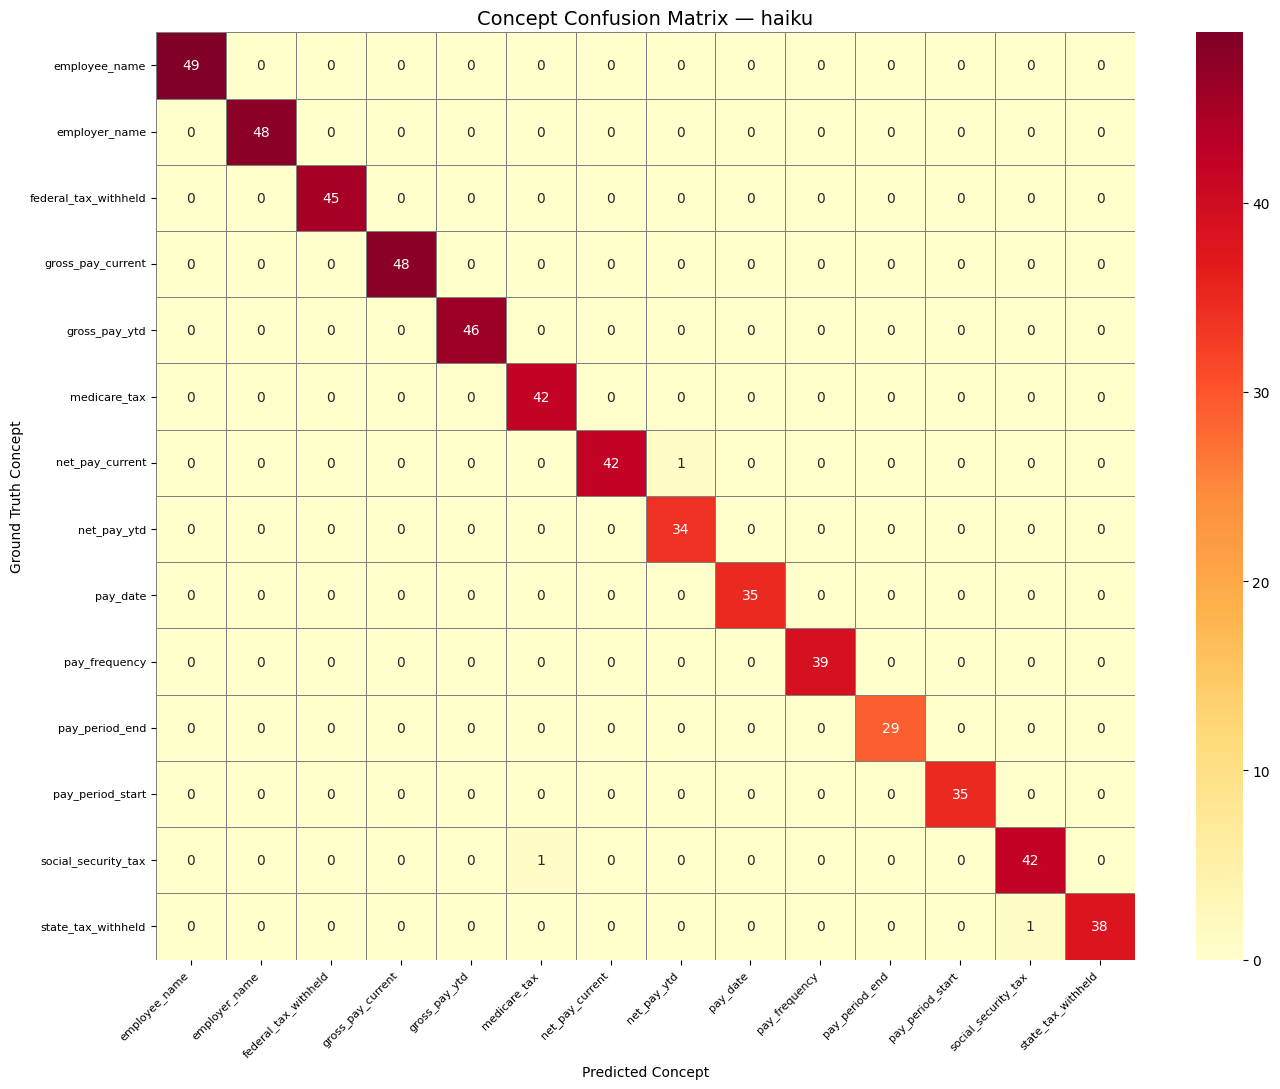


Top confusions (haiku):
         GT Concept        Pred Concept  Count Same Family?
    net_pay_current         net_pay_ytd      1          Yes
social_security_tax        medicare_tax      1          Yes
 state_tax_withheld social_security_tax      1          Yes

CONFUSION MATRIX — gpt4o-mini


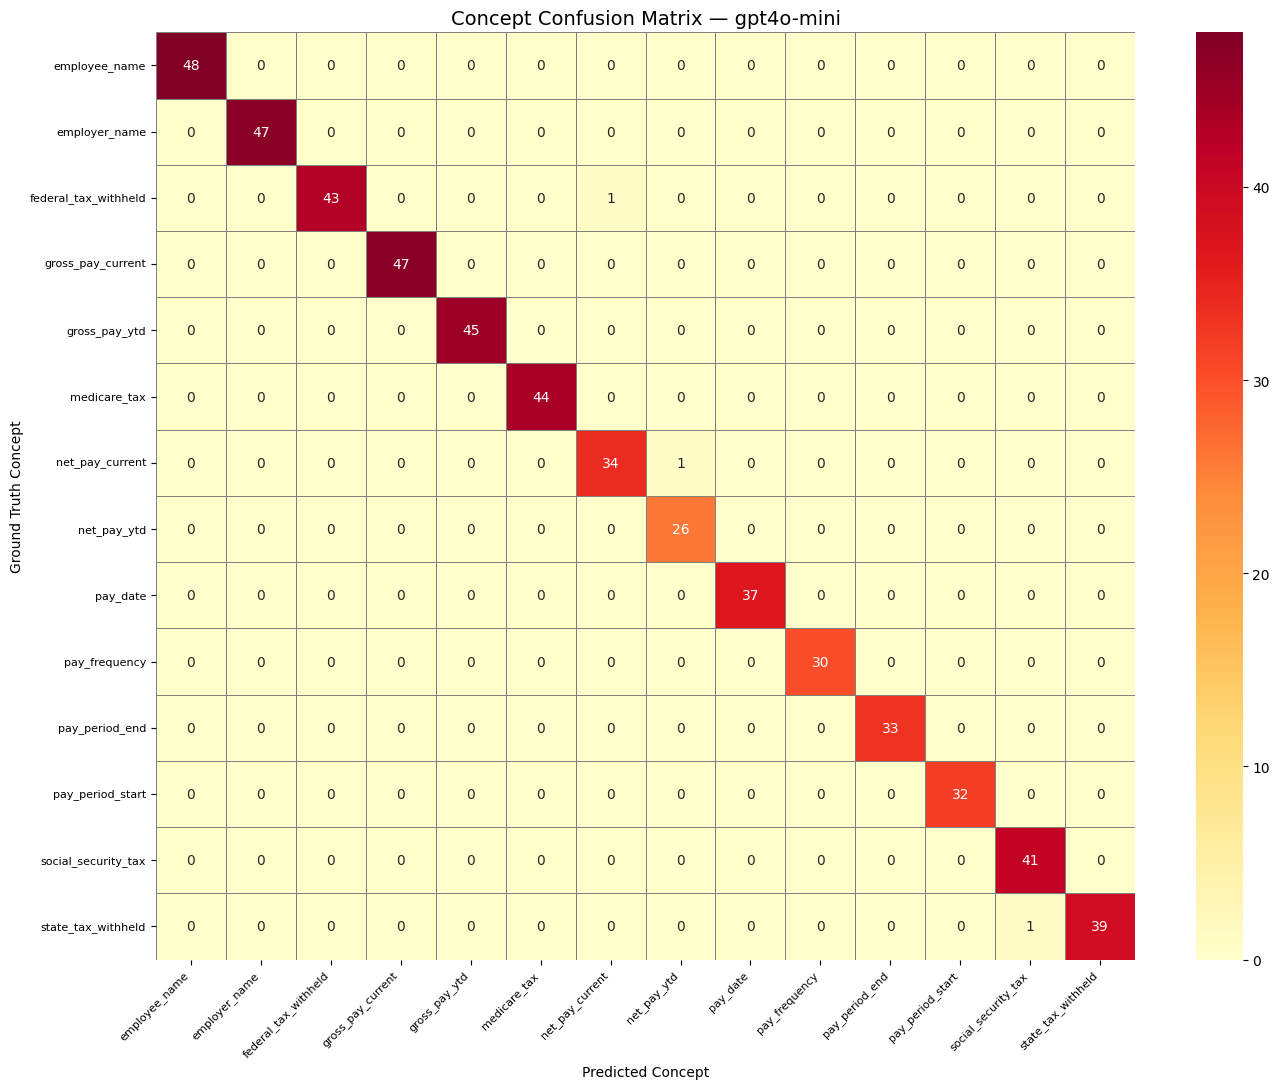


Top confusions (gpt4o-mini):
          GT Concept        Pred Concept  Count Same Family?
federal_tax_withheld     net_pay_current      1           No
     net_pay_current         net_pay_ytd      1          Yes
  state_tax_withheld social_security_tax      1          Yes


In [9]:
# Cell 9: Confusion Matrix

import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
except ImportError:
    HAS_PLOT = False

for model_name, results in experiments.items():
    print(f"\n{'='*60}")
    print(f"CONFUSION MATRIX — {model_name}")
    print(f"{'='*60}")

    scored_docs = results["per_document"]
    cm_data = build_confusion_matrix(scored_docs, ontology)

    # Filter to only EVAL_CONCEPTS for cleaner display
    eval_idx = [i for i, c in enumerate(cm_data["concepts"]) if c in EVAL_CONCEPTS]
    eval_concepts_sorted = [cm_data["concepts"][i] for i in eval_idx]
    matrix_np = np.array(cm_data["matrix"])
    filtered_matrix = matrix_np[np.ix_(eval_idx, eval_idx)]

    df_cm = pd.DataFrame(
        filtered_matrix,
        index=eval_concepts_sorted,
        columns=eval_concepts_sorted
    )

    # Display as heatmap
    if HAS_PLOT:
        fig, ax = plt.subplots(figsize=(14, 11))
        sns.heatmap(
            df_cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="gray",
            xticklabels=True, yticklabels=True,
        )
        ax.set_title(f"Concept Confusion Matrix — {model_name}", fontsize=14)
        ax.set_xlabel("Predicted Concept")
        ax.set_ylabel("Ground Truth Concept")
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print(df_cm.to_string())

    # Top confusions
    print(f"\nTop confusions ({model_name}):")
    top = top_confusions(cm_data, n=10)
    if top:
        top_rows = []
        for gt_c, pred_c, count in top:
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            top_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_top = pd.DataFrame(top_rows)
        print(df_top.to_string(index=False))
    else:
        print("  No off-diagonal confusions.")

In [10]:
# Cell 10: Export Results

# Collect all misbindings across models
all_misbinding_log = []
for model_name, results in experiments.items():
    all_misbinding_log.extend(results["misbinding_log"])

# Build confusion matrix data for export (combined)
all_scored_docs = []
for model_name, results in experiments.items():
    all_scored_docs.extend(results["per_document"])
combined_cm = build_confusion_matrix(all_scored_docs, ontology)

# Sample outputs for export (first 5 per model)
stage1_samples = {}
stage2_samples = {}
for model_name, results in experiments.items():
    stage1_samples[model_name] = [
        {"paystub_id": s["paystub_id"], "n_lines": s["n_lines"], "ocr_text": s["ocr_text"]}
        for s in results["stage1_raw_outputs"][:5]
    ]
    stage2_samples[model_name] = [
        {"paystub_id": s["paystub_id"], "n_mappings": s["n_mappings"], "mappings": s["mappings"]}
        for s in results["stage2_raw_outputs"][:5]
    ]

# Build exportable results
export_results = {
    "experiment": "hindsight_paystub_cba_v2",
    "prompt_design": "tesseract-ocr-plus-llm-array-output",
    "scoring": "value-first-matching",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "description": "Two-stage: Tesseract OCR → LLM array output {label,value,concept}. Value-first scoring detects misbindings (swaps).",
    "sample_size": len(sampled),
    "total_corpus": len(manifest),
    "eval_concepts": EVAL_CONCEPTS,
    "models": {
        model_name: {"model_id": cfg["model_id"], "provider": cfg["provider"]}
        for model_name, cfg in MODELS.items()
    },
    "results": {
        model_name: {
            "field_recall": results["field_recall"],
            "cba_strict": results["cba_strict"],
            "cba_soft": results["cba_soft"],
            "delta": results["delta"],
            "n_documents": results["n_documents"],
            "total_misbindings": results["total_misbindings"],
            "errors": len(results["errors"]),
            "per_document_summary": [
                {
                    "paystub_id": d["paystub_id"],
                    "layout": d["layout"],
                    "field_recall": d["field_recall"],
                    "cba_strict": d["cba_strict"],
                    "cba_soft": d["cba_soft"],
                    "delta": d["delta"],
                    "n_misbindings": d["n_misbindings"],
                }
                for d in results["per_document"]
            ],
        }
        for model_name, results in experiments.items()
    },
    "stage1_ocr_samples": stage1_samples,
    "stage2_mapping_samples": stage2_samples,
    "misbinding_log": all_misbinding_log,
    "confusion_matrix": {
        "concepts": combined_cm["concepts"],
        "matrix": combined_cm["matrix"],
        "families": combined_cm["families"],
    },
}

output_path = os.path.join(RESULTS_DIR, "hindsight_paystub_cba_v2_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, default=str)

print(f"Results exported to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

# Final summary
print(f"\n{'='*60}")
print("EXPERIMENT SUMMARY — v2 (Tesseract + LLM, value-first scoring)")
print(f"{'='*60}")
print(f"Sample size: {len(sampled)} / {len(manifest)} paystubs")
print(f"Concepts evaluated: {len(EVAL_CONCEPTS)}")
print(f"Pipeline: Tesseract OCR → LLM array mapping → value-first scoring")
for model_name, results in experiments.items():
    print(f"\n{model_name}:")
    print(f"  Field Recall:       {results['field_recall']:.4f}")
    print(f"  CBA-strict:     {results['cba_strict']:.4f}")
    print(f"  CBA-soft:       {results['cba_soft']:.4f}")
    print(f"  Delta (F1-CBA): {results['delta']:.4f}")
    print(f"  Misbindings:    {results['total_misbindings']}")
    kill_signal = results['delta'] >= 0.05
    print(f"  Kill signal:    {'YES (delta >= 5%)' if kill_signal else 'No (delta < 5%)'}")

Results exported to: /content/drive/MyDrive/hindsight/results/hindsight_paystub_cba_v2_results.json
File size: 53.5 KB

EXPERIMENT SUMMARY — v2 (Tesseract + LLM, value-first scoring)
Sample size: 50 / 200 paystubs
Concepts evaluated: 14
Pipeline: Tesseract OCR → LLM array mapping → value-first scoring

haiku:
  Field F1:       0.6703
  CBA-strict:     0.8222
  CBA-soft:       0.8243
  Delta (F1-CBA): -0.1519
  Misbindings:    3
  Kill signal:    No (delta < 5%)

gpt4o-mini:
  Field F1:       0.5792
  CBA-strict:     0.7845
  CBA-soft:       0.7859
  Delta (F1-CBA): -0.2053
  Misbindings:    3
  Kill signal:    No (delta < 5%)
